# Chapter 6 - Processing of the signal

Signal processing: interpolation/resampling, digital filters, the Hilbert transform.

> The narrative chapter is in [`docs/chap6.md`](docs/chap6.md). This notebook reproduces every figure and table from that chapter, organised section-by-section so the code is easy to read alongside the prose.


## Setup

Common imports, plot styling and data paths used throughout this notebook.


In [1]:
import bottleneck as bn
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scienceplots
import scipy
import scipy.signal
import scipy.special
import scipy.stats
import sklearn.decomposition
import astropy.io
import datetime
import astropy.time
import pandas as pd

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

read_path = 'docs/Data/'
save_path = 'docs/Figure/'

perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
matlab_perula = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_perula', np.array(perula_df))

jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')
matlab_jet = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_jet', np.array(jet_df))

%matplotlib ipympl

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_795031/3118345031.py:41: SyntaxWarning: invalid escape sequence '\s'
  perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
/tmp/ipykernel_795031/3118345031.py:44: SyntaxWarning: invalid escape sequence '\s'
  jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')


### `N = 2 ** 10`


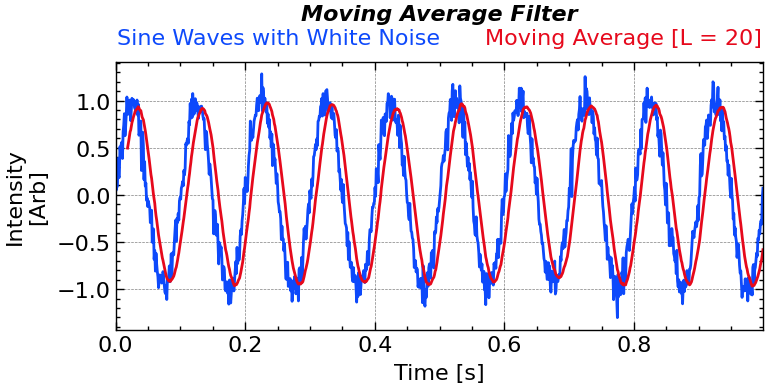

In [32]:
plt.close()
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(N)

plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)
ax1.plot(t, sig, color='C0', label='Sine Waves with White Noise')

sig_ma = bn.move_mean(sig, 20)
ax1.plot(t, sig_ma, 'C1-', label='Moving Average [L = 20]')
ax1.legend(loc = 'upper center', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, frameon = False, bbox_to_anchor=(0.5, 1.2))
ax1.set_title('Moving Average Filter', fontdict=title_font, pad = 30)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
plt.tight_layout()
ax1.autoscale(enable=True, axis='x', tight=True)
plt.savefig(save_path + 'figure_moving_average' + '.png', bbox_inches='tight', dpi=300)

plt.show()

### `image = np.array(Image.open(read_path + 'leena.png').convert('L')).astype(float)`


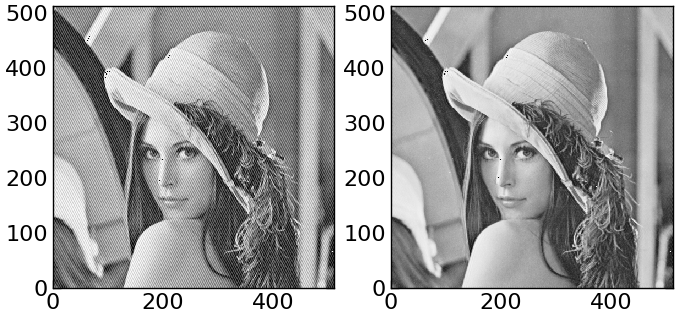

In [148]:
from PIL import Image
image = np.array(Image.open(read_path + 'leena.png').convert('L')).astype(float)

image += 30 * np.cos(np.linspace(0, 2 * np.pi, image.shape[0])[:, None] * 64.0 + \
                     np.linspace(0, 2 * np.pi, image.shape[1])[None, :] * 128.0)
image = image.astype(np.uint8)

plt.close()
ax1 = plt.subplot(1, 2, 1, aspect='equal')
ax2 = plt.subplot(1, 2, 2, aspect='equal')

# ax1.imshow(image)
ax1.pcolormesh(255 - image[::-1, ::-1], cmap='Greys', vmax = 255, vmin = 0)
image_fft = np.fft.fft2(image.astype(float))
image_fft[::, ::][64 - 30 : 64 + 30, 128 - 30 : 128 + 30] = 0
image_fft[::-1, ::][64 - 30 : 64 + 30, 128 - 30 : 128 + 30] = 0
image_fft[::, ::-1][64 - 30 : 64 + 30, 128 - 30 : 128 + 30] = 0
image_fft[::-1, ::-1][64 - 30 : 64 + 30, 128 - 30 : 128 + 30] = 0
# for i in range(60, image_fft.shape[1] - 60):
#     image_fft[i - 60 : i + 60, i] = 0
image_fft = np.fft.fftshift(image_fft)
# sigma = 60
# image_fft[]
# image_fft *= np.exp(-0.5 * (np.arange(image_fft.shape[1]) - image_fft.shape[1] // 2) ** 2 / sigma ** 2)[None, :]
# image_fft *= np.exp(-0.5 * (np.arange(image_fft.shape[0]) - image_fft.shape[0] // 2) ** 2 / sigma ** 2)[:, None]
image_fft = np.fft.fftshift(image_fft)
image = np.fft.ifft2(image_fft)
ax2.pcolormesh(255 - image[::-1, ::-1].real, cmap='Greys', vmax = 255, vmin = 0)
# ax2.pcolormesh(np.abs(image_fft), cmap = 'jet', norm = matplotlib.colors.LogNorm(vmin = 1e3, vmax = 1e6))


### `image.shape`


In [84]:
image.shape

(512, 512)

### `N = 2 ** 10`


[-36.87856014  32.37424447  16.65554763 ...   0.64079998   0.24860884
  -0.51220258]


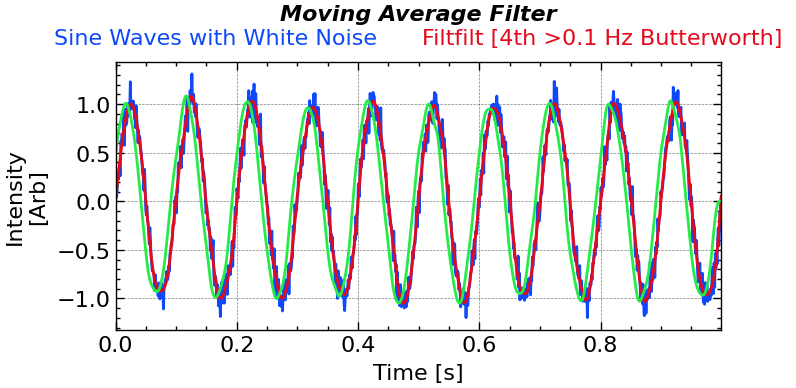

In [46]:
plt.close()
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(N)

plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)
ax1.plot(t, sig, color='C0', label='Sine Waves with White Noise')

sos = scipy.signal.butter(4, 0.1, 'low', output='sos')
sig_filtfilt = scipy.signal.sosfiltfilt(sos, sig)
ax1.plot(t, sig_filtfilt, 'C1-', label='Filtfilt [4th >0.1 Hz Butterworth]')

sig_filt = scipy.signal.sosfilt(sos, sig[::-1])[::-1]
sig_filt_filt = scipy.signal.sosfilt(sos, sig_filt)

print((sig_filtfilt / sig_filt_filt))
ax1.plot(t, sig_filt, 'C2-')

ax1.legend(loc = 'upper center', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, frameon = False, bbox_to_anchor=(0.5, 1.2))
ax1.set_title('Moving Average Filter', fontdict=title_font, pad = 30)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
plt.tight_layout()
ax1.autoscale(enable=True, axis='x', tight=True)
# plt.savefig(save_path + 'figure_filtfilt' + '.png', bbox_inches='tight', dpi=300)

plt.show()

### Interpolation methods compared

Nearest, linear, Akima, cubic spline, sinc, and Fourier interpolation applied to the same sparsely-sampled signal.

In [ ]:
import scipy.interpolate

plt.close()
plt.figure(figsize=(8, 6), tight_layout=True)
ax1 = plt.subplot(1, 1, 1)
N = 2 ** 4
omega0 = 2 * np.pi * 1.1

t = np.arange(0, N + 1) / N
t = np.linspace(0, 1, N, endpoint = False)

dt = t[1] - t[0]
sig = np.sin(omega0 * t) + np.sin(omega0 * 2 * t)

ax1.plot(t, sig, 'ko', label = 'Sample', zorder = 3)

nearest_interp = scipy.interpolate.interp1d(t, sig, kind = 'nearest', bounds_error = False)
linear_interp = scipy.interpolate.interp1d(t, sig, bounds_error = False)
akima_interp = scipy.interpolate.Akima1DInterpolator(t, sig)
cubic_interp = scipy.interpolate.CubicSpline(t, sig)

def sinc_interp(t_interp):
    weight = np.sinc((t_interp[:, None] - t[None, :]) / dt)
    return weight @ sig

n_interp = 2 ** 4 * N
t_interp = np.arange(0, n_interp) / n_interp

gap = 0.5
sig_interp = np.sin(omega0 * t_interp) + np.sin(omega0 * 2 * t_interp)
for i in range(7):
    if i == 0:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.15, label = 'Ground Truth')
    else:
        ax1.plot(t_interp, sig_interp + i * gap, 'k-', alpha = 0.15)

ax1.step(t_interp, nearest_interp(t_interp) + 1 * gap, label = 'Nearest', where = 'mid')
ax1.plot(t_interp, linear_interp(t_interp) + 2 * gap, label = 'Linear')
ax1.plot(t_interp, akima_interp(t_interp) + 3 * gap, label = 'Akima')
ax1.plot(t_interp, cubic_interp(t_interp) + 4 * gap, label = 'Cubic')
ax1.plot(t_interp, sinc_interp(t_interp) + 5 * gap, label = 'Sinc')
ax1.plot(t_interp, scipy.signal.resample(sig, t_interp.size) + 6 * gap, label = 'Fourier')

ax1.axvspan(t[-1], 1, 0, 1.0, color = '#888888', edgecolor = 'none', zorder = 2, alpha = 0.5)
ax1.text((t[-1] + 1) / 2, -0.7, 'Right Bound', rotation = 90,          fontsize=14,
         color='w',
         ha='center',
         va='center',
         weight='bold', path_effects = path_effect)
ax1.autoscale(axis = 'x', tight = True)

ax1.legend(frameon = False, ncol = 2, loc = 'upper center')
ax1.set_title('Interpolation & Interpolator', **title_font)

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_ylim(-2.1, 6.2)

plt.tight_layout()
# ax1.grid('off')

plt.savefig(save_path + 'figure_interpolation' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Causal (`sosfilt`) vs zero-phase (`sosfiltfilt`) filtering

Comparing the phase delay of a causal Butterworth filter with the zero-phase forward-backward version.

In [ ]:
import scipy.signal

plt.close()
ax1 = plt.subplot(1, 1, 1)
N = 2 ** 10
t = np.linspace(0, 1, N, endpoint=False)
fs = 1 / (t[1] - t[0])
omega = 2 * np.pi * 8.0
sig = np.sin(omega * t) + np.random.randn(t.size) * 0.2

ax1.plot(t, sig, 'k-', alpha = 0.3)

sos = scipy.signal.butter(1, [6, 10], btype = 'bandpass', output='sos', fs = fs)
filtered_signal = scipy.signal.sosfilt(sos, sig)
ax1.plot(t, filtered_signal, 'C0', label = 'sosfilt')

filtered_signal = scipy.signal.sosfiltfilt(sos, sig)
ax1.plot(t, filtered_signal, 'C1', label = 'sosfiltfilt')

ax1.legend(frameon = False, bbox_to_anchor = (0.5, 1.02), loc = 'upper center', ncol = 2)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_ylim(-1.7, 1.7)
ax1.set_title('Second Order Sections\n5-Butterworth 6-10 Hz Bandpass Filter', **title_font)
plt.tight_layout()
ax1.autoscale(axis = 'x', tight= True)

plt.savefig(save_path + 'figure_filtered_signal' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Filter types in the time domain

Buttherworth, elliptic, Chebyshev-I, Bessel, and FIR window filters applied to the same signal.

In [ ]:
plt.close()
plt.figure(figsize = (8, 6))
ax1 = plt.subplot(1, 1, 1)

N = 2 ** 10
omega0 = 2 * np.pi * 64

t = np.linspace(0, 1, N, endpoint = False)

dt = t[1] - t[0]
sig = np.sin(omega0 * t) + np.sin(omega0 * 2 * t) + np.random.randn(t.size) * 0.0

plt.close()
# plt.figure(figsize = (8, 6))
ax1 = plt.subplot(1, 1, 1)

fs = 1 / dt
cutoff = 1.5 * omega0 / 2 / np.pi
cutoff = 96

N = 10
rp = 3
rs = 10
firwin_b = scipy.signal.firwin(numtaps=N, cutoff=cutoff, fs=fs, width=3)
# FIR 不需要 sos

butter_sos = scipy.signal.butter(N=N, Wn=cutoff, fs=fs, output='sos')
bessel_sos = scipy.signal.bessel(N=N, Wn=cutoff, fs=fs, output='sos')
cheby1_sos = scipy.signal.cheby1(N=N, rp=rp, Wn=cutoff, fs=fs, output='sos')
ellip_sos = scipy.signal.ellip(N=N, rp=rp, rs=rs, Wn=cutoff, fs=fs, btype='lowpass', output='sos')

gap = 2.0


for i in range(6):
    ax1.plot(t, i * gap + np.sin(omega0 * t), 'k-', alpha=0.25, label = "Ground Truth" if i == 0 else None)


ax1.plot(t, sig, 'ko-', label='Input')
ax1.plot(t, 1 * gap + scipy.signal.sosfiltfilt(butter_sos, sig), label='Butterworth', linestyle='--', alpha=0.75)
ax1.plot(t, 5 * gap + scipy.signal.filtfilt(firwin_b, 1, sig), label='FIR Window', linestyle='--', alpha=0.75)
ax1.plot(t, 3 * gap + scipy.signal.sosfiltfilt(cheby1_sos, sig), label='Chebyshev-I [rp = 3]', linestyle='--', alpha=0.75)
ax1.plot(t, 4 * gap + scipy.signal.sosfiltfilt(bessel_sos, sig), label='Bessel', linestyle='--', alpha=0.75)
ax1.plot(t, 2 * gap + scipy.signal.sosfiltfilt(ellip_sos, sig), label='Elliptic [rp = 3, rs = 10]', linestyle='--', alpha=0.75)

ax1.axvspan(0.99, 1.0, color = '#888888', edgecolor = 'none')
ax1.text(0.993, 11.5, 'Edge Effect', **title_font, rotation = 90, color = 'w', path_effects = path_effect)
ax1.set_ylim(-2.3, 17.8)

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_title('N-th Order Filter' + f" [N={N}]", **title_font)
ax1.autoscale(axis = 'x', tight = True)
ax1.set_xlim(0.9, 1.0)
ax1.legend(frameon = False, ncol = 2, loc = 'upper left')
plt.tight_layout()

plt.savefig(save_path + 'figure_filters' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Filter frequency responses

Frequency-domain magnitude response (dB) of the same five IIR/FIR filter designs.

In [ ]:
plt.close()
plt.figure(figsize = (8, 6))

ax1 = plt.subplot(1, 1, 1)

fs = 1024.0  # Hz
cutoff = 96.0  # Hz

N = 10
rp = 3
rs = 10

butter_b, butter_a = scipy.signal.butter(N = N, Wn = cutoff, fs = fs)
butter_w, butter_h = scipy.signal.freqz(butter_b, butter_a, fs = fs)

bessel_b, bessel_a = scipy.signal.bessel(N = N, Wn = cutoff, fs = fs)
bessel_w, bessel_h = scipy.signal.freqz(bessel_b, bessel_a, fs = fs)

firwin_b = scipy.signal.firwin(numtaps=N, cutoff = cutoff, fs = fs, width = 3)
firwin_w, firwin_h = scipy.signal.freqz(firwin_b, fs = fs)

cheby1_b, cheby1_a = scipy.signal.cheby1(N = N, rp = rp, Wn = cutoff, fs = fs)
cheby1_w, cheby1_h = scipy.signal.freqz(cheby1_b, cheby1_a, fs = fs)

ellip_b, ellip_a = scipy.signal.ellip(N = N, rp = rp, rs = rs, Wn = cutoff, fs = fs, btype = 'lowpass')
ellip_w, ellip_h = scipy.signal.freqz(ellip_b, ellip_a, fs = fs)

# Butterworth Filter (sos version)
butter_sos = scipy.signal.butter(N=N, Wn=cutoff, fs=fs, output='sos')
butter_w, butter_h = scipy.signal.sosfreqz(butter_sos, fs=fs)

# Bessel Filter (sos version)
bessel_sos = scipy.signal.bessel(N=N, Wn=cutoff, fs=fs, output='sos')
bessel_w, bessel_h = scipy.signal.sosfreqz(bessel_sos, fs=fs)

# FIR Filter (FIR filters are already stable and linear-phase, no sos form)
firwin_b = scipy.signal.firwin(numtaps=N, cutoff=cutoff, fs=fs, width=3)
firwin_w, firwin_h = scipy.signal.freqz(firwin_b, fs=fs)

# Chebyshev Type I Filter (sos version)
cheby1_sos = scipy.signal.cheby1(N=N, rp=rp, Wn=cutoff, fs=fs, output='sos')
cheby1_w, cheby1_h = scipy.signal.sosfreqz(cheby1_sos, fs=fs)

# Elliptic Filter (sos version)
ellip_sos = scipy.signal.ellip(N=N, rp=rp, rs=rs, Wn=cutoff, fs=fs, btype='lowpass', output='sos')
ellip_w, ellip_h = scipy.signal.sosfreqz(ellip_sos, fs=fs)

ax1.plot(firwin_w, 20 * np.log10(np.abs(firwin_h)), label = 'Firwin', linestyle = '-', alpha = 0.75)
ax1.plot(butter_w, 20 * np.log10(np.abs(butter_h)), label = 'Butterworth', linestyle = '-', alpha = 0.75)
ax1.plot(bessel_w, 20 * np.log10(np.abs(bessel_h)), label = 'Bessel', linestyle = '-', alpha = 0.75)
ax1.plot(cheby1_w, 20 * np.log10(np.abs(cheby1_h)), label = 'Chebyshev-I [rp = 3]', linestyle = '-', alpha = 0.75)
ax1.plot(ellip_w, 20 * np.log10(np.abs(ellip_h)), label = 'Elliptic [rp = 3, rs = 10]', linestyle = '-', alpha = 0.75)
ax1.hlines([-rp, -rs], 0, fs / 2, color = 'w', linestyle = '-', linewidth = 1.0, path_effects = path_effect)

ax1.pcolormesh(butter_w, np.array([-120, 10]), np.outer(20 * np.log10(np.abs(butter_h)), np.ones(2)).T, cmap = 'Reds_r', vmax = 0, vmin = -40, alpha = 0.5)

ax1.legend(frameon = False, ncol = 1, loc = 'lower left')

ax1.set_title('N-th Order Filter\nFrequency Response' + f" [N={N}]", **title_font)
ax1.text(24, 2, 'Passband', **title_font, color = 'w', path_effects = path_effect, va = 'top')
ax1.text(120, 2, 'Transition\nBand', **title_font, color = 'w', path_effects = path_effect, ha = 'center', va = 'top')
ax1.text(152, 2, 'Stopband', **title_font, color = 'w', path_effects = path_effect, va = 'top')

ax1.text(2.02 * cutoff, -rs, 'rs', **title_font, ha = 'left', va = 'center', color = 'w', path_effects = path_effect)
ax1.text(2.02 * cutoff, -rp, 'rp', **title_font, ha = 'left', va = 'center', color = 'w', path_effects = path_effect)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.set_xlim(0, 2 * cutoff)
ax1.set_ylim(-20, 3)

ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Attenuation [dB]')

plt.savefig(save_path + 'figure_filters_response' + '.png',bbox_inches='tight',dpi=300)

plt.show()

### Hilbert transform

The Hilbert transform produces the analytic signal whose imaginary part is the 90-degree phase-shifted version of the real input; the magnitude gives the instantaneous envelope.

In [ ]:
import scipy.signal

plt.close()
plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)

omega = 2 * np.pi * 8.0
t = np.linspace(0, 1, 2 ** 7, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(omega * t) * (0.1 + np.hanning(t.size)) + np.random.randn(t.size) * 0.0

ax1.plot(t, sig, 'ko-')

ax1.plot(t, scipy.signal.hilbert(sig).real, 'r--', label = 'Real', alpha = 0.5)
ax1.plot(t, scipy.signal.hilbert(sig).imag, 'b--', label = 'Imaginary', alpha = 0.5)
ax1.plot(t, np.abs(scipy.signal.hilbert(sig)), 'k--', label = 'Magnitude', alpha = 0.5)
ax1.plot(t, -np.abs(scipy.signal.hilbert(sig)), 'k--', alpha = 0.5)

ax1.set_xlim(-0.0, 1.0)

for ax in [ax1]:
    ax.grid('on', linestyle = '--', alpha = 0.5)

ax1.legend(frameon = False, loc = 'upper center', ncol = 3, bbox_to_anchor = (0.5, 1.17))

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity [Arb]')
ax1.set_title('Hilbert Transform', y = 1.09, **title_font)

plt.tight_layout()

plt.savefig(save_path + 'figure_hilbert' + '.png',bbox_inches='tight',dpi=300)

plt.show()

## Further reading

The narrative chapter, complete with derivations and references, is in [`docs/chap6.md`](docs/chap6.md). For the full table of contents see [`docs/_sidebar.md`](docs/_sidebar.md).
